# Hands-On Lab — Logistic Regression & Decision Trees
**Data Science Techniques and Real-World Applications — WS 2026**

**Zahra Sharafi**

**Frankfurt School of Finance and Management**

A practical, from-scratch walkthrough of two classifiers on one familiar real-world problem:
**should a bank approve a loan application?** We'll build a small, realistic loan-applicant
dataset, then compare how logistic regression and a decision tree each handle it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

C:\Users\sharafi\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## The data: loan applicants

Three things a bank actually looks at when deciding whether to approve a loan:
- **Credit score** (300–850): higher is better.
- **Debt-to-income ratio**: the share of monthly income already going to debt payments. Higher is riskier.
- **Years employed**: a longer, steadier employment history is generally seen as lower risk.

The target, `Default`, is 1 if the applicant later defaults on the loan, 0 if they don't. This is
a simulated dataset (built so the relationships are realistic and clean enough to see clearly),
but the shape of the problem is exactly what a real credit-risk model looks like.

In [2]:
np.random.seed(42)
n = 400

credit_score = np.random.normal(650, 80, n).clip(300, 850)
debt_to_income = np.random.uniform(0.05, 0.6, n)
years_employed = np.random.exponential(5, n).clip(0, 30)

# the "true" (hidden, in real life) relationship: low credit score, high debt-to-income,
# and little work history all push default risk up
risk_score = -0.035 * (credit_score - 650) + 6 * (debt_to_income - 0.3) - 0.08 * years_employed
default_probability = 1 / (1 + np.exp(-risk_score))
default = (np.random.rand(n) < default_probability).astype(int)

loans = pd.DataFrame({
    "CreditScore": credit_score.round(0),
    "DebtToIncome": debt_to_income.round(3),
    "YearsEmployed": years_employed.round(1),
    "Default": default,
})

print(f"{len(loans)} applicants, {loans['Default'].mean():.1%} defaulted")
loans.head()

400 applicants, 43.2% defaulted


,CreditScore,DebtToIncome,YearsEmployed,Default
0,690.0,0.278,1.6,0
1,639.0,0.200,3.9,0
2,702.0,0.081,5.0,0
3,772.0,0.526,1.5,0
4,631.0,0.497,0.8,1


## Logistic regression: how much does each factor matter?

Fit a logistic regression on all three features. Logistic regression's big strength here: every
coefficient has a direct, explainable meaning — exactly what a bank's risk team (and regulators)
want from a loan-approval model.

In [3]:
X = loans[["CreditScore", "DebtToIncome", "YearsEmployed"]].values
y = loans["Default"].values

logreg = LogisticRegression()
logreg.fit(X, y)

for name, coef in zip(["CreditScore", "DebtToIncome", "YearsEmployed"], logreg.coef_[0]):
    print(f"{name:15s} coefficient = {coef:+.4f}   odds ratio = {np.exp(coef):.3f}")

print(f"\naccuracy:  {logreg.score(X, y):.3f}")
print(f"base rate (always predict the majority class): {max(y.mean(), 1 - y.mean()):.3f}")

CreditScore     coefficient = -0.0297   odds ratio = 0.971
DebtToIncome    coefficient = +3.2692   odds ratio = 26.291
YearsEmployed   coefficient = -0.0329   odds ratio = 0.968

accuracy:  0.802
base rate (always predict the majority class): 0.568


**Reading the odds ratios:**
- `CreditScore` odds ratio is just under 1: each extra point of credit score multiplies the odds
  of default by a little less than 1 — i.e. default odds *shrink* with every point. Over 100
  points, that compounds into a large effect.
- `DebtToIncome` odds ratio is far above 1: a higher debt load sharply *increases* default odds —
  the strongest single factor here.
- `YearsEmployed` odds ratio is just under 1: more years employed modestly *lowers* default odds.

This is exactly the kind of sentence a bank can put in a credit-decision explanation letter —
logistic regression's coefficients translate directly into "why was this application rejected?"

### Seeing the decision boundary

To visualize what the model is actually doing, drop down to the two strongest features
(`CreditScore`, `DebtToIncome`) and plot the boundary it draws between "likely to repay" and
"likely to default."

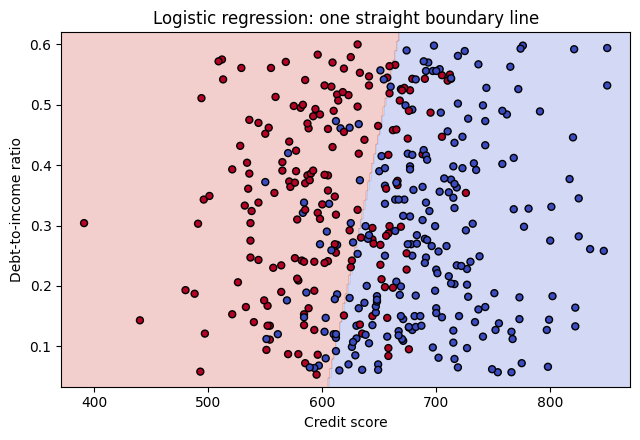

In [4]:
X2 = loans[["CreditScore", "DebtToIncome"]].values

logreg2 = LogisticRegression().fit(X2, y)

def plot_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 20, X[:, 0].max() + 20
    y_min, y_max = X[:, 1].min() - 0.02, X[:, 1].max() + 0.02
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(6.5, 4.5))
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k", s=25)
    ax.set_xlabel("Credit score")
    ax.set_ylabel("Debt-to-income ratio")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

plot_boundary(logreg2, X2, y, "Logistic regression: one straight boundary line")

## Decision tree: the same problem, a different kind of rule

A decision tree doesn't draw one straight boundary — it asks a sequence of yes/no questions
("Is credit score below 600? Is debt-to-income above 0.4?") and splits the data at each answer.
Fit one at `max_depth=3` so it stays small enough to read directly, like a bank's actual
underwriting checklist.

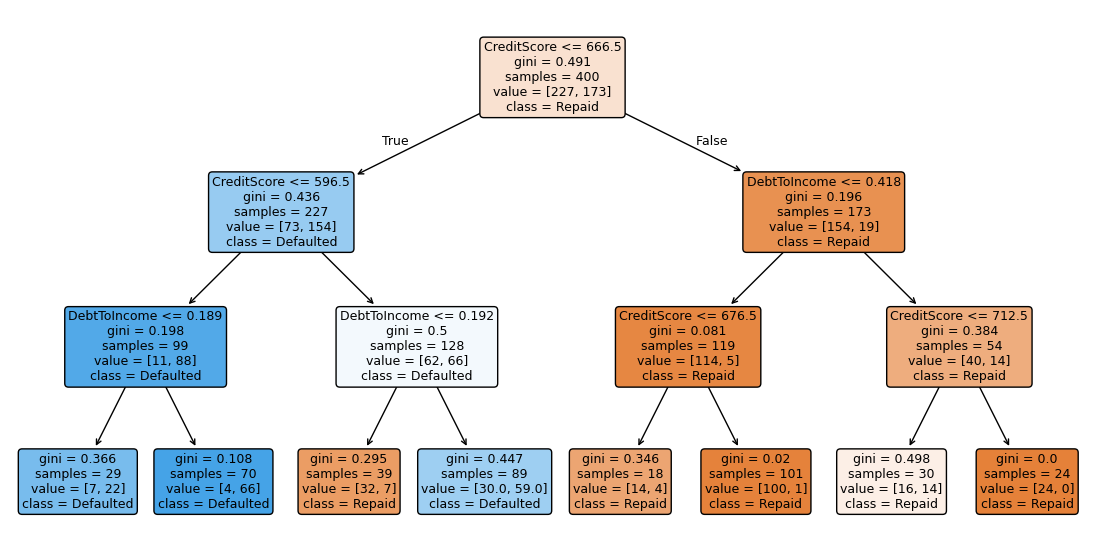

accuracy: 0.833


In [5]:
tree2 = DecisionTreeClassifier(max_depth=3, random_state=0)
tree2.fit(X2, y)

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(tree2, feature_names=["CreditScore", "DebtToIncome"], class_names=["Repaid", "Defaulted"],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.show()

print(f"accuracy: {tree2.score(X2, y):.3f}")

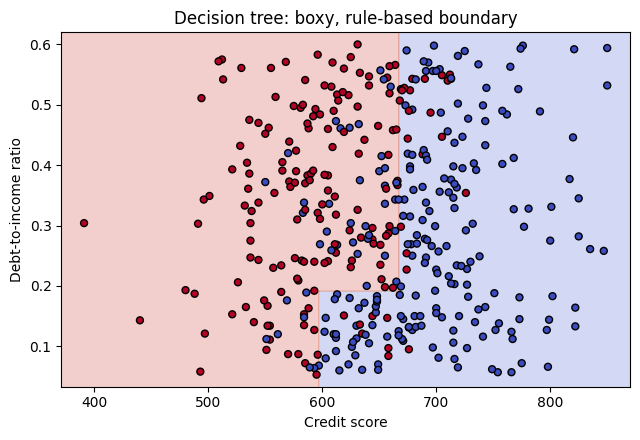

In [6]:
plot_boundary(tree2, X2, y, "Decision tree: boxy, rule-based boundary")

### The core difference, visually

- **Logistic regression** draws one smooth, straight boundary — it assumes risk changes gradually
  and consistently as credit score or debt-to-income move.
- **Decision tree** draws a boundary made of straight-line "steps" — it can carve out rectangular
  pockets of risk (e.g. "fine, unless credit score *and* debt-to-income are both bad"), capturing
  interactions a single straight line can't.

Neither is "better" in general: logistic regression is easier to explain and regulate (one
coefficient per factor); a tree can capture more complex, rule-like patterns but is easier to
overfit (recall `max_depth` from the course material) and its explanation gets more complex as it
grows deeper.

## Try it on one applicant

A new applicant: credit score 600, debt-to-income 0.45, employed 1 year. What does each model say?

In [7]:
new_applicant = pd.DataFrame({
    "CreditScore": [600],
    "DebtToIncome": [0.45],
    "YearsEmployed": [1.0],
})

logreg_prob = logreg.predict_proba(new_applicant.values)[0, 1]
tree_full = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X, y)
tree_prob = tree_full.predict_proba(new_applicant.values)[0, 1]

print(f"logistic regression: P(default) = {logreg_prob:.2f}")
print(f"decision tree:        P(default) = {tree_prob:.2f}")

logistic regression: P(default) = 0.84
decision tree:        P(default) = 0.66


## Takeaways

- Both models agree: this applicant is high-risk (weak credit score, high debt load, short work
  history) — but they arrive at that number differently, and disagree on *exactly* how risky.
- **Use logistic regression** when you need a transparent, auditable "why" for every decision
  (loan approvals, credit scoring, anything regulated).
- **Use a decision tree** when the real-world rule is naturally "if-then" shaped, or you suspect
  factors interact (e.g. "debt-to-income only matters if credit score is already weak").
- In practice, both get compared on held-out data before either goes into production — exactly
  what Session 4, Block 2 covers next (train/test split, and why accuracy alone isn't enough).